Import Libraries

In [17]:
import jax
import flax
import optax
from jax import lax, random, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import os
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated


In [18]:
n_gpu = len(jax.devices())
jax.devices()

[CudaDevice(id=0)]

In [19]:
# For PC
DATA_DIR = Path.cwd().parent.parent / "data"

In [20]:
DATA_FILE = DATA_DIR / "data_T20_S30_G50.dat"

dat = np.loadtxt(DATA_FILE, skiprows=1, delimiter=',') # data on CPU
print (dat.shape)

# swap header for non reduced dataset as it was not labelled properly
if DATA_FILE == DATA_DIR / "data_T20_S30_G50.dat":
    dat[:, [0, 1]] = dat[:, [1, 0]]

# crop to focus on area of interest in the grid
# dat = dat[(dat[:,1] > 150) & (dat[:,1] < 350)] # selects all rows where the y-coordinate falls strictly between 150 and 350

# Calculate dimensions
nx = len(np.unique(dat[:, 0])) # take every row in x col 
ny = len(np.unique(dat[:, 1])) # take every row in y col

print(dat.shape)
print(f"Grid dimensions: nx={nx}, ny={ny}")
print(np.unique(dat[:,0]).shape, np.unique(dat[:,1]).shape) # unique coordinate values along each individual axis

x_l, x_u, y_l, y_u = np.unique(dat[:,0]).min(), np.unique(dat[:,0]).max(), np.unique(dat[:,1]).min(), np.unique(dat[:,1]).max()
ext = [x_l, x_u, y_l, y_u] # plot boundary
print(ext)

(491520, 4)
(491520, 4)
Grid dimensions: nx=960, ny=512
(960,) (512,)
[np.float64(0.5), np.float64(959.5), np.float64(0.5), np.float64(511.5)]


Text(0.5, 1.0, 'Solution')

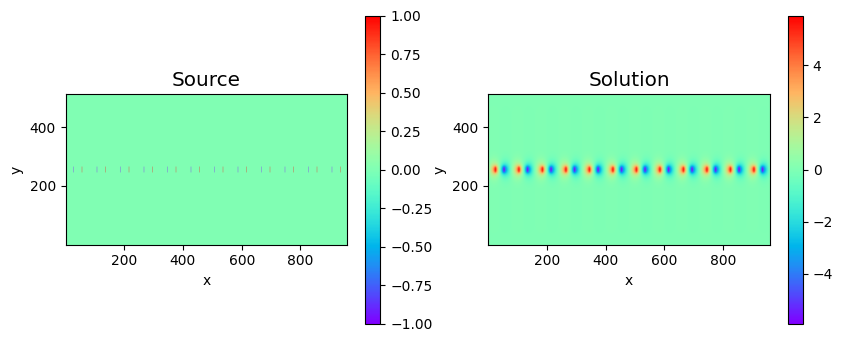

In [21]:
"""
Plot the system with boundaries as the perimeter of the plot
"""
# Source
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1,2,1)
s_plot = dat[:,2].reshape(nx, ny).T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y')
plt.title('Source', fontsize='x-large')

# Solution
ax1 = fig.add_subplot(1,2,2)
s_plot = dat[:,3].reshape(nx, ny).T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2); plt.xlabel('x'); plt.ylabel('y')
plt.title('Solution', fontsize='x-large')

In [22]:
dat = jnp.array(dat) # data now on GPU
x, y, s, u_sim = dat[:,0].reshape(-1, 1), dat[:,1].reshape(-1, 1), dat[:,2].reshape(-1, 1), dat[:,3].reshape(-1, 1)

# Neumann Boundaries (Top and Bottom edges)
bc_n = ((y == y_l) | (y == y_u)).flatten()
print('Neumann BC: #sample = %d'%bc_n.sum())

# Boundary Conditions (bc), Periodic upper (pu) and Periodic  lower (pl)
bc_pl, bc_pu = ((x == x_l)).flatten(), ((x == x_u)).flatten()
print('Periodic BC: #sample = %d %d'%(bc_pl.sum(), bc_pu.sum()))

# bc_d = ((y == y_l) | (y == y_u) | (x == x_l) | (x == x_u)).flatten()
# print ('Dirichlet BC: #sample = %d'%bc_d.sum())

# Boundary points for mini-batching
x_n, y_n = x[bc_n], y[bc_n]
x_pl, y_pl = x[bc_pl], y[bc_pl]
x_pu, y_pu = x[bc_pu], y[bc_pu]

Neumann BC: #sample = 1920
Periodic BC: #sample = 512 512


In [23]:
s_flat = s.flatten()

source_indices = jnp.where(jnp.abs(s_flat) > 1e-4)[0]
empty_indices = jnp.where(jnp.abs(s_flat) <= 1e-4)[0]

num_source_points = source_indices.shape[0]
print(f"Found {num_source_points} active source pixels out of {s_flat.shape[0]}.")

Found 480 active source pixels out of 491520.


In [24]:
M = 256 
hidden_layers = [128, 128, 128, 128] 
total_features = (2 * M) + sum(hidden_layers) # 512 + 512 = 1024

rff_key = jax.random.PRNGKey(99)
B_matrix_base = jax.random.normal(rff_key, (2, M)) 

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):
        sigma = 2.8931 

        # raw_sigma = self.param('raw_sigma', nn.initializers.constant(2.85), (1,))
        # sigma = jax.nn.softplus(raw_sigma) # so sigma dont go negative
        
        raw_tik = self.param('raw_tik', nn.initializers.constant(-4.0), (1,))
        
        # Normalization
        x_norm = 2.0 * (x_in - x_l) / (x_u - x_l) - 1.0
        y_norm = 2.0 * (y_in - y_l) / (y_u - y_l) - 1.0
        v = jnp.concatenate([x_norm, y_norm], axis=-1)

        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix_base * sigma)
        h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)], axis=-1)
        all_features = [h_rff]

        h = h_rff
        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
            all_features.append(h)
            
        return jnp.concatenate(all_features, axis=-1)
    
model = FeatureExtractor(
    hidden_layers=hidden_layers, 
    B_matrix_base=B_matrix_base 
)

key = jax.random.PRNGKey(0)
dummy_x = jnp.array([0.0])
dummy_y = jnp.array([0.0])
params = model.init(key, dummy_x, dummy_y)

def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_x = jacfwd(get_f, argnums=1)(params, x_val, y_val)
    f_y = jacfwd(get_f, argnums=2)(params, x_val, y_val)
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    
    f_x = jnp.squeeze(f_x, axis=-1)
    f_y = jnp.squeeze(f_y, axis=-1)
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))
    return f_x, f_y, f_xx, f_yy

f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))

In [25]:
chunk_size = 256

def get_f_chunk(params, x_val, y_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, end_idx):
    # f_y is needed for the Neumann Boundaries
    f_y = jacfwd(get_f_chunk, argnums=2)(params, x_val, y_val, start_idx, end_idx)
    
    f_xx = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_yy = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, start_idx, end_idx)
    
    # Squeeze out the inner gradient dimensions to match expected shapes
    f_y = jnp.squeeze(f_y, axis=-1)
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))
    
    return f_y, f_xx, f_yy

f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))

In [26]:
@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_direct_solve(params, x_pde, y_pde, s_pde, x_n, y_n, x_pl, y_pl, x_pu, y_pu, total_features, chunk_size, tik_reg):
    A_chunks = []
    
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        
        # PDE Interior
        _, f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        A_pde_chunk = (f_xx + f_yy) / 100.0
        
        # Neumann BC (f_y = 0)
        f_y_n, _, _ = f_dir_chunk_spatial_vmap(params, x_n, y_n, start_idx, end_idx)
        A_nbc_chunk = f_y_n
        
        # Periodic BC (f_pl - f_pu = 0)
        f_pl = f_chunk_spatial_vmap(params, x_pl, y_pl, start_idx, end_idx)
        f_pu = f_chunk_spatial_vmap(params, x_pu, y_pu, start_idx, end_idx)
        A_pbc_chunk = f_pl - f_pu
        
        A_chunk = jnp.vstack([A_pde_chunk, A_nbc_chunk, A_pbc_chunk])
        A_chunks.append(A_chunk)
        
    # full A matrix (no optimization done)
    A = jnp.hstack(A_chunks)
    
    b_pde = s_pde / 100.0
    b_nbc = jnp.zeros((x_n.shape[0], 1))
    b_pbc = jnp.zeros((x_pl.shape[0], 1))
    b = jnp.vstack([b_pde, b_nbc, b_pbc])
    
    # Solve w using Tikhonov Regularized Normal Equations
    AtA = A.T @ A + tik_reg * jnp.eye(total_features)
    Atb = A.T @ b
    
    w_new = jnp.linalg.solve(AtA, Atb)
    
    return w_new

In [27]:
def get_u(params, x_val, y_val, w_current):
    f = model.apply(params, x_val, y_val)
    return jnp.dot(f, w_current) 

def get_u_dir(params, x_val, y_val, w_current):
    u_y = jacfwd(get_u, argnums=2)(params, x_val, y_val, w_current)
    u_xx = jacfwd(jacfwd(get_u, argnums=1), argnums=1)(params, x_val, y_val, w_current)
    u_yy = jacfwd(jacfwd(get_u, argnums=2), argnums=2)(params, x_val, y_val, w_current)
    
    u_y = jnp.squeeze(u_y)
    u_xx = jnp.squeeze(u_xx)
    u_yy = jnp.squeeze(u_yy)
    
    return u_y, u_xx, u_yy

u_spatial_vmap = vmap(get_u, in_axes=(None, 0, 0, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None))

In [28]:
def full_forward_and_loss(params, x_pde, y_pde, s_pde, u_sim_pde, x_n, y_n, x_pl, y_pl, x_pu, y_pu, total_features, chunk_size):
    # tik_reg = 7.90e-06 # this is for reduced dataset

    raw_tik = params['params']['raw_tik'][0]
    tik_reg = 10.0 ** raw_tik

    w_current = update_direct_solve(params, x_pde, y_pde, s_pde, x_n, y_n, x_pl, y_pl, x_pu, y_pu, total_features, chunk_size, tik_reg)
    
    # u_sim loss 
    f_pde = f_spatial_vmap(params, x_pde, y_pde)
    u_pred = jnp.dot(f_pde, w_current)
    loss_data = jnp.mean((jnp.squeeze(u_pred) - jnp.squeeze(u_sim_pde)) ** 2)
    
    # physics loss
    _, u_xx, u_yy = u_dir_spatial_vmap(params, x_pde, y_pde, w_current)
    pde_residual = ((u_xx + u_yy) - jnp.squeeze(s_pde)) / 100.0
    loss_pde = jnp.mean(pde_residual ** 2)
     
    # boundary loss
    u_y_n, _, _ = u_dir_spatial_vmap(params, x_n, y_n, w_current)
    loss_n = jnp.mean(u_y_n ** 2)
    
    u_pl = jnp.squeeze(u_spatial_vmap(params, x_pl, y_pl, w_current))
    u_pu = jnp.squeeze(u_spatial_vmap(params, x_pu, y_pu, w_current))
    loss_p = jnp.mean((u_pl - u_pu) ** 2)
    
    total_loss =  loss_pde + loss_n + loss_p
    
    return total_loss, (w_current, loss_data, loss_pde, tik_reg)

loss_grad_fn = jax.jit(
    jax.value_and_grad(full_forward_and_loss, argnums=0, has_aux=True), 
    static_argnames=['total_features', 'chunk_size']
)

optimizer = optax.adamw(learning_rate=1e-3, weight_decay=1e-4)

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_network(params, opt_state, x_pde, y_pde, s_pde, u_sim_pde, x_n, y_n, x_pl, y_pl, x_pu, y_pu, total_features, chunk_size):
    (loss, (w_current, loss_data, loss_pde, tik_reg)), grads = loss_grad_fn(
        params, x_pde, y_pde, s_pde, u_sim_pde, x_n, y_n, x_pl, y_pl, x_pu, y_pu, total_features, chunk_size
    )
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, opt_state, loss, w_current, loss_data, loss_pde, tik_reg

In [29]:
"""For tuning sigma and tikreg"""
# def full_forward_and_loss(params, x_pde, y_pde, s_pde, u_sim_pde, x_n, y_n, x_pl, y_pl, x_pu, y_pu, total_features, chunk_size):
    
#     # Extract trainable parameters
#     raw_tik = params['params']['raw_tik'][0]
#     tik_reg = 10.0 ** raw_tik 
    
#     # Extract Sigma to trigger gradient tracking
#     sigma = jax.nn.softplus(params['params']['raw_sigma'][0])
    
#     w_current = update_direct_solve(params, x_pde, y_pde, s_pde, x_n, y_n, x_pl, y_pl, x_pu, y_pu, total_features, chunk_size, tik_reg)
    
#     # SUPERVISED DATA LOSS (With Squeeze Fix)
#     f_pde = f_spatial_vmap(params, x_pde, y_pde)
#     u_pred = jnp.dot(f_pde, w_current)
#     loss_data = jnp.mean((jnp.squeeze(u_pred) - jnp.squeeze(u_sim_pde)) ** 2)
    
#     u_y_n, _, _ = u_dir_spatial_vmap(params, x_n, y_n, w_current)
#     loss_n = jnp.mean(u_y_n ** 2)
    
#     u_pl = jnp.squeeze(u_spatial_vmap(params, x_pl, y_pl, w_current))
#     u_pu = jnp.squeeze(u_spatial_vmap(params, x_pu, y_pu, w_current))
#     loss_p = jnp.mean((u_pl - u_pu) ** 2)
    
#     total_loss = loss_data + loss_n + loss_p
    
#     # Return both sigma and tik_reg in the aux data
#     return total_loss, (w_current, sigma, tik_reg)

# loss_grad_fn = jax.jit(
#     jax.value_and_grad(full_forward_and_loss, argnums=0, has_aux=True), 
#     static_argnames=['total_features', 'chunk_size']
# )

# optimizer = optax.adamw(learning_rate=1e-3, weight_decay=1e-4) # can drop to 5e-4 

# @jax.jit(static_argnames=['total_features', 'chunk_size'])
# def update_network(params, opt_state, x_pde, y_pde, s_pde, u_sim_pde, x_n, y_n, x_pl, y_pl, x_pu, y_pu, total_features, chunk_size):
#     (loss, (w_current, current_sigma, current_tik)), grads = loss_grad_fn(
#         params, x_pde, y_pde, s_pde, u_sim_pde, x_n, y_n, x_pl, y_pl, x_pu, y_pu, total_features, chunk_size
#     )
#     updates, opt_state = optimizer.update(grads, opt_state, params=params)
#     new_params = optax.apply_updates(params, updates)
    
#     return new_params, opt_state, loss, w_current, current_sigma, current_tik

'For tuning sigma and tikreg'

In [ ]:
"""Using 2000 coordinates in 1 pass"""
epochs = 3000 
spatial_batch_size = 2000
bc_batch_size = 250 

opt_state = optimizer.init(params)
w_final = None 

total_points = x.shape[0]
total_n_points = x_n.shape[0]
total_p_points = x_pl.shape[0]

n_batch_size = min(bc_batch_size, total_n_points)
p_batch_size = min(bc_batch_size, total_p_points)

rng = jax.random.PRNGKey(42)

for epoch in tqdm(range(epochs), desc="Batched Training Phase"):
    rng, s_key, e_key, n_key, p_key = jax.random.split(rng, 5)
    
    num_actual_sources = source_indices.shape[0]
    
    # Take all of the source points (No replacement needed)
    # We cap it at 1000 just in case we change datasets later
    n_sources_to_sample = min(1000, num_actual_sources)
    s_idx = jax.random.choice(s_key, source_indices, shape=(n_sources_to_sample,), replace=False)
    
    # Fill the rest of the 2000-point batch quota with empty space
    n_empty_to_sample = 2000 - n_sources_to_sample
    e_idx = jax.random.choice(e_key, empty_indices, shape=(n_empty_to_sample,), replace=False)
    
    # Combine them into a 2000-point batch
    pde_idx = jnp.concatenate([s_idx, e_idx])
    
    # Sample Interior Points including u_sim
    x_pde_chunk = x[pde_idx]
    y_pde_chunk = y[pde_idx]
    s_pde_chunk = s[pde_idx]
    u_sim_pde_chunk = u_sim[pde_idx] 
    
    # Sample Neumann Boundaries
    n_idx = jax.random.choice(n_key, total_n_points, shape=(n_batch_size,), replace=False)
    x_n_chunk = x_n[n_idx]
    y_n_chunk = y_n[n_idx]
    
    # Sample Periodic Boundaries
    p_idx = jax.random.choice(p_key, total_p_points, shape=(p_batch_size,), replace=False)
    x_pl_chunk = x_pl[p_idx]
    y_pl_chunk = y_pl[p_idx]
    x_pu_chunk = x_pu[p_idx] 
    y_pu_chunk = y_pu[p_idx] 
    
    # Batched Update Step
    params, opt_state, loss, w_current, l_data, l_pde, tik_reg = update_network(
        params, opt_state, 
        x_pde_chunk, y_pde_chunk, s_pde_chunk, u_sim_pde_chunk, 
        x_n_chunk, y_n_chunk, 
        x_pl_chunk, y_pl_chunk, x_pu_chunk, y_pu_chunk, 
        total_features, chunk_size
    )
    
    # Keep the latest w_current for the final full-grid evaluation
    w_final = w_current
    
    if epoch % 50 == 0:
        tqdm.write(f"Epoch {epoch:03d} | Total: {loss:.4e} | Data: {l_data:.4e} | PDE: {l_pde:.4e} | Tik: {tik_reg:.2e}")

Batched Training Phase:   0%|          | 0/3000 [00:00<?, ?it/s]

Epoch 000 | Total: 2.1390e-05 | Data: 1.0036e+01 | PDE: 2.0686e-05 | Tik: 1.00e-04
Epoch 050 | Total: 7.4977e-06 | Data: 2.1620e+02 | PDE: 5.9548e-06 | Tik: 8.89e-05
Epoch 100 | Total: 4.0841e-06 | Data: 2.2889e+02 | PDE: 2.8659e-06 | Tik: 8.15e-05
Epoch 150 | Total: 2.6683e-06 | Data: 1.8137e+02 | PDE: 1.9488e-06 | Tik: 7.67e-05
Epoch 200 | Total: 1.9061e-06 | Data: 1.3160e+02 | PDE: 1.3018e-06 | Tik: 7.38e-05
Epoch 250 | Total: 1.0995e-06 | Data: 9.2257e+01 | PDE: 8.0768e-07 | Tik: 7.18e-05
Epoch 300 | Total: 7.4410e-07 | Data: 6.3372e+01 | PDE: 6.1239e-07 | Tik: 7.03e-05
Epoch 350 | Total: 5.0916e-07 | Data: 3.8739e+01 | PDE: 4.2629e-07 | Tik: 6.95e-05
Epoch 400 | Total: 4.0618e-07 | Data: 2.7530e+01 | PDE: 3.2761e-07 | Tik: 6.89e-05
Epoch 450 | Total: 5.1232e-07 | Data: 1.9388e+01 | PDE: 4.7084e-07 | Tik: 6.85e-05
Epoch 500 | Total: 3.2083e-07 | Data: 1.4471e+01 | PDE: 2.7757e-07 | Tik: 6.82e-05
Epoch 550 | Total: 2.8984e-07 | Data: 9.6832e+00 | PDE: 2.5839e-07 | Tik: 6.79e-05
Epoc

In [31]:
"""Using all coordinates in 1 pass"""
# # For training with u_sim + physics loss
# epochs = 400
# opt_state = optimizer.init(params)
# w_final = None 

# for epoch in tqdm(range(epochs)):
    
#     params, opt_state, loss, w_current, l_data, l_pde = update_network(params, opt_state, x, y, s, u_sim, x_n, y_n, x_pl, y_pl, x_pu, y_pu, total_features, chunk_size)
#     w_final = w_current
    
#     if epoch % 10 == 0:
#         tqdm.write(f"Epoch {epoch:03d} | Total: {loss:.4e} | Data Loss: {l_data:.4e} | PDE Loss: {l_pde:.4e}")

# # # For tuning sigma and tikreg with only u_sim loss
# # for epoch in tqdm(range(epochs)):
    
# #     # Pass the full grid into the update step
# #     params, opt_state, loss, w_current, curr_sigma, curr_tik = update_network(params, opt_state, x, y, s, u_sim, x_n, y_n, x_pl, y_pl, x_pu, y_pu, total_features, chunk_size)
# #     w_final = w_current
# #     if epoch % 10 == 0:
# #         tqdm.write(f"Epoch {epoch:03d} | Loss: {loss:.4e} | Sigma: {curr_sigma:.4f} | Tik Reg: {curr_tik:.2e}")

'Using all coordinates in 1 pass'

Evaluating full grid safely in chunks...
Final Metrics -> MSE: 4.48e-01 | MAE: 4.92e-01 | RL2: 1.06e+00


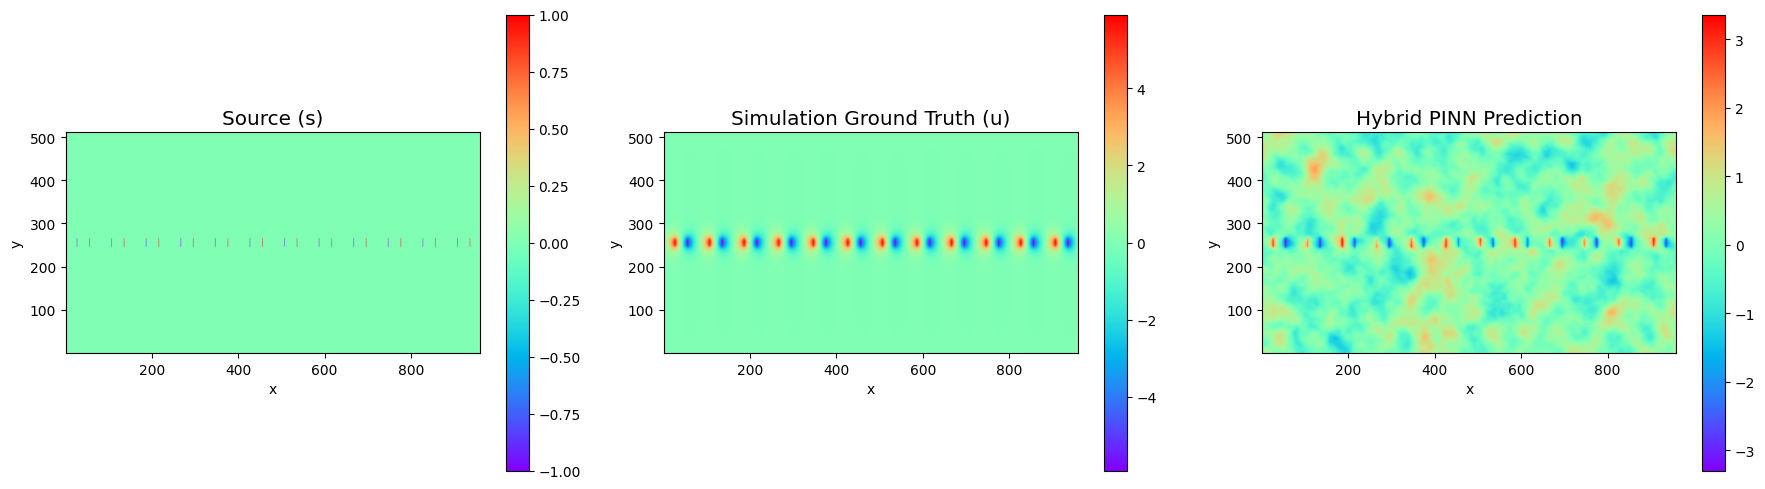

In [32]:
print("Evaluating full grid safely in chunks...")

chunk_size_eval = 10000 
u_pred_list = []

for i in range(0, x.shape[0], chunk_size_eval):
    x_c = x[i : i+chunk_size_eval]
    y_c = y[i : i+chunk_size_eval]
    
    f_chunk = f_spatial_vmap(params, x_c, y_c)
    
    u_chunk = jnp.dot(f_chunk, w_final)
    u_pred_list.append(u_chunk)

u_pred = jnp.vstack(u_pred_list)

mse = jnp.mean((u_sim - u_pred)**2)
mae = jnp.mean(jnp.abs(u_sim - u_pred))
rl2 = jnp.linalg.norm(u_sim - u_pred) / jnp.linalg.norm(u_sim)

print(f"Final Metrics -> MSE: {mse:.2e} | MAE: {mae:.2e} | RL2: {rl2:.2e}")

s_plot = s.reshape(nx, ny).T
u_sim_plot = u_sim.reshape(nx, ny).T
u_pred_plot = u_pred.reshape(nx, ny).T

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(1, 3, 1)
mesh1 = ax1.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=ax1)
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.set_title('Source (s)', fontsize='x-large')

ax2 = fig.add_subplot(1, 3, 2)
mesh2 = ax2.imshow(u_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=ax2)
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('Simulation Ground Truth (u)', fontsize='x-large')

ax3 = fig.add_subplot(1, 3, 3)
mesh3 = ax3.imshow(u_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=ax3)
ax3.set_xlabel('x'); ax3.set_ylabel('y')
ax3.set_title('Hybrid PINN Prediction', fontsize='x-large')

plt.tight_layout()
plt.show()